# Problem 16 (Rectified Flow on MNIST Generation)

Try flow MNIST with UNet

In [ ]:
!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

Cloning into 'rectified-flow'...
remote: Enumerating objects: 1403, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 1403 (delta 84), reused 66 (delta 64), pack-reused 1250 (from 1)
Receiving objects: 100% (1403/1403), 58.02 MiB | 35.01 MiB/s, done.
Resolving deltas: 100% (906/906), done.
/content/rectified-flow


In [ ]:
import math
import numpy as np
import torch
import torch.utils.checkpoint
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms
from tqdm.auto import tqdm

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.utils import match_dim_with_data
from rectified_flow.utils import plot_cifar_results

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

## Load dataset

In [ ]:
batch_size = 512

transform_list = [
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
]
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.Compose(transform_list)
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

batch = next(iter(train_dataloader))
print(batch[0].shape)  # torch.Size([256, 1, 28, 28])

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.57MB/s]


torch.Size([512, 1, 28, 28])


## Train Unconditional Generation

In [ ]:
import copy
import os
import torch

class EMAModel:
    def __init__(
        self,
        net: torch.nn.Module,
        ema_halflife_kimg: float = 2000.0,
        ema_rampup_ratio: float = 0.05,
    ):
        self.net = net
        self.ema = copy.deepcopy(net).eval().float()
        for param in self.ema.parameters():
            param.requires_grad_(False)
        self.ema_halflife_kimg = ema_halflife_kimg
        self.ema_rampup_ratio = ema_rampup_ratio

    @torch.no_grad()
    def update(self, cur_nimg: int, batch_size: int):
        """
        Update EMA parameters using a half-life strategy.

        Args:
            cur_nimg (int): The current number of images (could be total images processed so far).
            batch_size (int): The global batch size.
        """
        ema_halflife_nimg = self.ema_halflife_kimg * 1000

        if self.ema_rampup_ratio is not None:
            ema_halflife_nimg = min(ema_halflife_nimg, cur_nimg * self.ema_rampup_ratio)

        beta = 0.5 ** (batch_size / max(ema_halflife_nimg, 1e-8))

        for p_ema, p_net in zip(self.ema.parameters(), self.net.parameters()):
            p_ema.copy_((p_net.float()).lerp(p_ema, beta))

    def apply_shadow(self):
        """
        Copy EMA parameters back to the original `net`.
        """
        for p_net, p_ema in zip(self.net.parameters(), self.ema.parameters()):
            p_net.data.copy_(p_ema.data.to(p_net.dtype))

    def save_pretrained(self, save_directory: str, filename: str = "unet"):
        """
        Save the EMA model parameters to a file.
        """
        if not os.path.exists(save_directory):
            os.makedirs(save_directory)
        state_dict_cpu = {k: v.cpu() for k, v in self.ema.state_dict().items()}
        output_model_file = os.path.join(save_directory, f"{filename}_ema.pt")
        torch.save(state_dict_cpu, output_model_file)
        print(f"EMA model weights saved to {output_model_file}")

    def load_pretrained(self, save_directory: str, filename: str = "unet"):
        """
        Load EMA model parameters from a file.
        """
        output_model_file = os.path.join(save_directory, f"{filename}_ema.pt")
        if os.path.exists(output_model_file):
            state_dict = torch.load(output_model_file, map_location="cpu")
            self.ema.load_state_dict(state_dict, strict=True)
            net_device = next(self.net.parameters()).device
            self.ema.to(device=net_device, dtype=torch.float32)
            print(f"EMA weights loaded from {output_model_file}")
        else:
            print(f"No EMA weights found at {output_model_file}")

In [ ]:
from rectified_flow.models.unet import SongUNet, SongUNetConfig
config = SongUNetConfig(
    img_resolution = 28,
    in_channels = 1,                  # Number of color channels at input.
    out_channels = 1,                 # Number of color channels at output.
    label_dim = 0,                    # Number of class labels, 0 = unconditional.
    augment_dim = 0,                  # Augmentation label dimensionality, 0 = no augmentation.

    model_channels = 64,                # Base multiplier for the number of channels.
    channel_mult = [2, 2],              # Channel multipliers for each resolution.
    channel_mult_emb = 2,               # Multiplier for the dimensionality of the embedding vector.
    num_blocks = 2,                     # Number of residual blocks per resolution.
    attn_resolutions = [14],            # Resolutions at which to apply attention.
    dropout = 0.13,                     # Dropout probability of intermediate activations.
    label_dropout = 0.0,                # Dropout probability of class labels for classifier-free guidance.
    embedding_type = "positional",      # Timestep embedding type: 'positional' or 'fourier'.
    channel_mult_time = 1,              # Timestep embedding size: 1 for DDPM++, 2 for NCSN++.
    encoder_type = "standard",          # Encoder architecture: 'standard' or 'residual'.
    decoder_type = "standard",          # Decoder architecture: 'standard' or 'residual'.
    resample_filter = [1, 1]
)
flow_model = SongUNet(config)
data_shape = (1, 28, 28)
flow_model = flow_model.to(device)

print(f"Number of parameters in flow model: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")

ema_flow = EMAModel(flow_model, ema_halflife_kimg=1.0, ema_rampup_ratio=0.05)

optimizer = torch.optim.AdamW(
    flow_model.parameters(),
    lr=5e-4, weight_decay=0.01,
    betas=(0.9, 0.95)
)

compiled_flow = torch.compile(flow_model, mode="reduce-overhead", fullgraph=False, dynamic=False)

compiled_flow.train()
optimizer.zero_grad()

Number of parameters in flow model: 5,631,873


In [ ]:
epoch = 200
# If you have A100 GPU, can set epoch to 200
cur_nimg = 0

try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

def safe_tqdm_write(msg: str):
    try:
        tqdm.write(msg)
    except Exception:
        print(msg)

zero_to_none = True
grad_clip_norm = None

global_step = 0
running_loss = None
smooth_alpha = 0.99

# test model
with torch.no_grad():
    batch = next(iter(train_dataloader))
    x_1, c = batch
    x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(x_1.shape[0], device=x_1.device)
    v_pred = flow_model(x_1, t)
    print(x_1.shape, x_0.shape, v_pred.shape)
    sq_err = (v_pred - (x_1 - x_0)).pow(2).sum(dim=1)
    loss = sq_err.mean()
    safe_tqdm_write(f"Initial test loss: {loss.item():.4f}")

torch.Size([512, 1, 28, 28]) torch.Size([512, 1, 28, 28]) torch.Size([512, 1, 28, 28])
Initial test loss: 1.9247


In [ ]:
train_loss_history = []
for ep in tqdm(range(epoch), desc="Epochs", position=0):
    compiled_flow.train()
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)

        B = x_1.shape[0]
        t = torch.rand(B, device=x_1.device, dtype=x_1.dtype)
        t_b = t.view(B, 1, 1, 1)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_t = t_b * x_1 + (1 - t_b) * x_0
            dot_x_t = x_1 - x_0
            v_pred = compiled_flow(x_t, t)

        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())

        loss_value = loss.item()
        train_loss_history.append(loss_value)

        loss.backward()
        optimizer.step()

        global_step += 1
        cur_nimg += B
        ema_flow.update(cur_nimg=cur_nimg, batch_size=B)  # assuming this mutates from current params

        loss_val = float(loss.detach().item())
        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * loss_val
        )

        pbar.set_postfix({
            "mse_loss": f"{loss_val:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    safe_tqdm_write(f"[epoch {ep+1}/{epoch}] steps={global_step:,} mse_loss={loss_val:.4f}, mse_loss_ema={running_loss:.4f}")

    if ep % 10 == 0:
        flow_model.save_pretrained(f"./checkpoints/flow_mnist")   # will overwrite; add suffix if you want snapshots
        ema_flow.save_pretrained(f"./checkpoints/flow_mnist")


print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

ep 1/200:   0%|          | 0/118 [00:00<?, ?it/s]

skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_21). Found from : 
   File "/content/rectified-flow/rectified_flow/models/unet.py", line 387, in forward
    x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
  File "/content/rectified-flow/rectified_flow/models/unet.py", line 185, in forward
    x = x * self.skip_scale

skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_21). Found from : 
   File "/content/rectified-flow/rectified_flow/models/unet.py", line 387, in forward
    x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
  File "/content/rectified-flow/rectified_flow/models/unet.py", line 185, in forward
    x = x * self.skip_scale



[epoch 1/200] steps=118 mse_loss=0.2521, mse_loss_ema=0.8440
Configuration saved to ./checkpoints/flow_mnist/unet_config.json
Model weights saved to ./checkpoints/flow_mnist/unet_model.pt
EMA model weights saved to ./checkpoints/flow_mnist/unet_ema.pt


ep 2/200:   0%|          | 0/118 [00:00<?, ?it/s]

...

[epoch 198/200] steps=23,364 mse_loss=0.1563, mse_loss_ema=0.1617


ep 199/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 199/200] steps=23,482 mse_loss=0.1562, mse_loss_ema=0.1616


ep 200/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 200/200] steps=23,600 mse_loss=0.1548, mse_loss_ema=0.1618
Training done. Total steps: 23,600, last loss: 0.1548, EMA: 0.1618


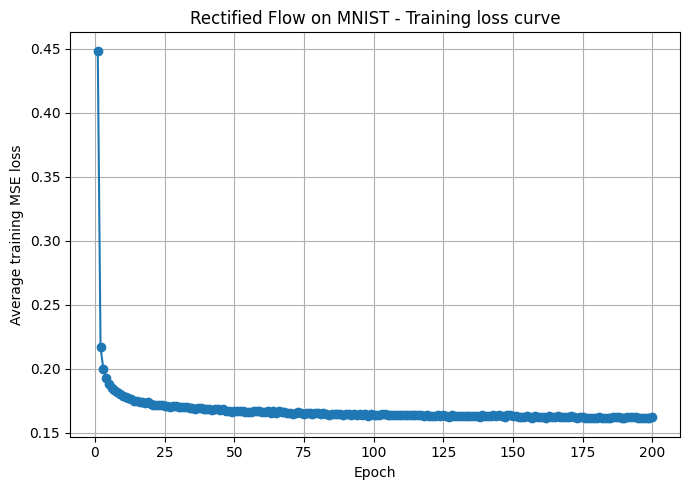

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

steps_per_epoch = len(train_dataloader)
history = np.array(train_loss_history, dtype=np.float32)

if history.size == 0:
    raise ValueError("train_loss_history is empty; run the training loop first.")

epoch_losses = history.reshape(-1, steps_per_epoch).mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average training MSE loss")
plt.title("Rectified Flow on MNIST - Training loss curve")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from rectified_flow.samplers import EulerSampler, SDESampler

ema_flow.apply_shadow()
model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

euler_sampler = EulerSampler(rf_inference, num_steps=200)
sde_sampler = SDESampler(rf_inference, num_steps=200, noise_scale=5, noise_decay_rate=0.)

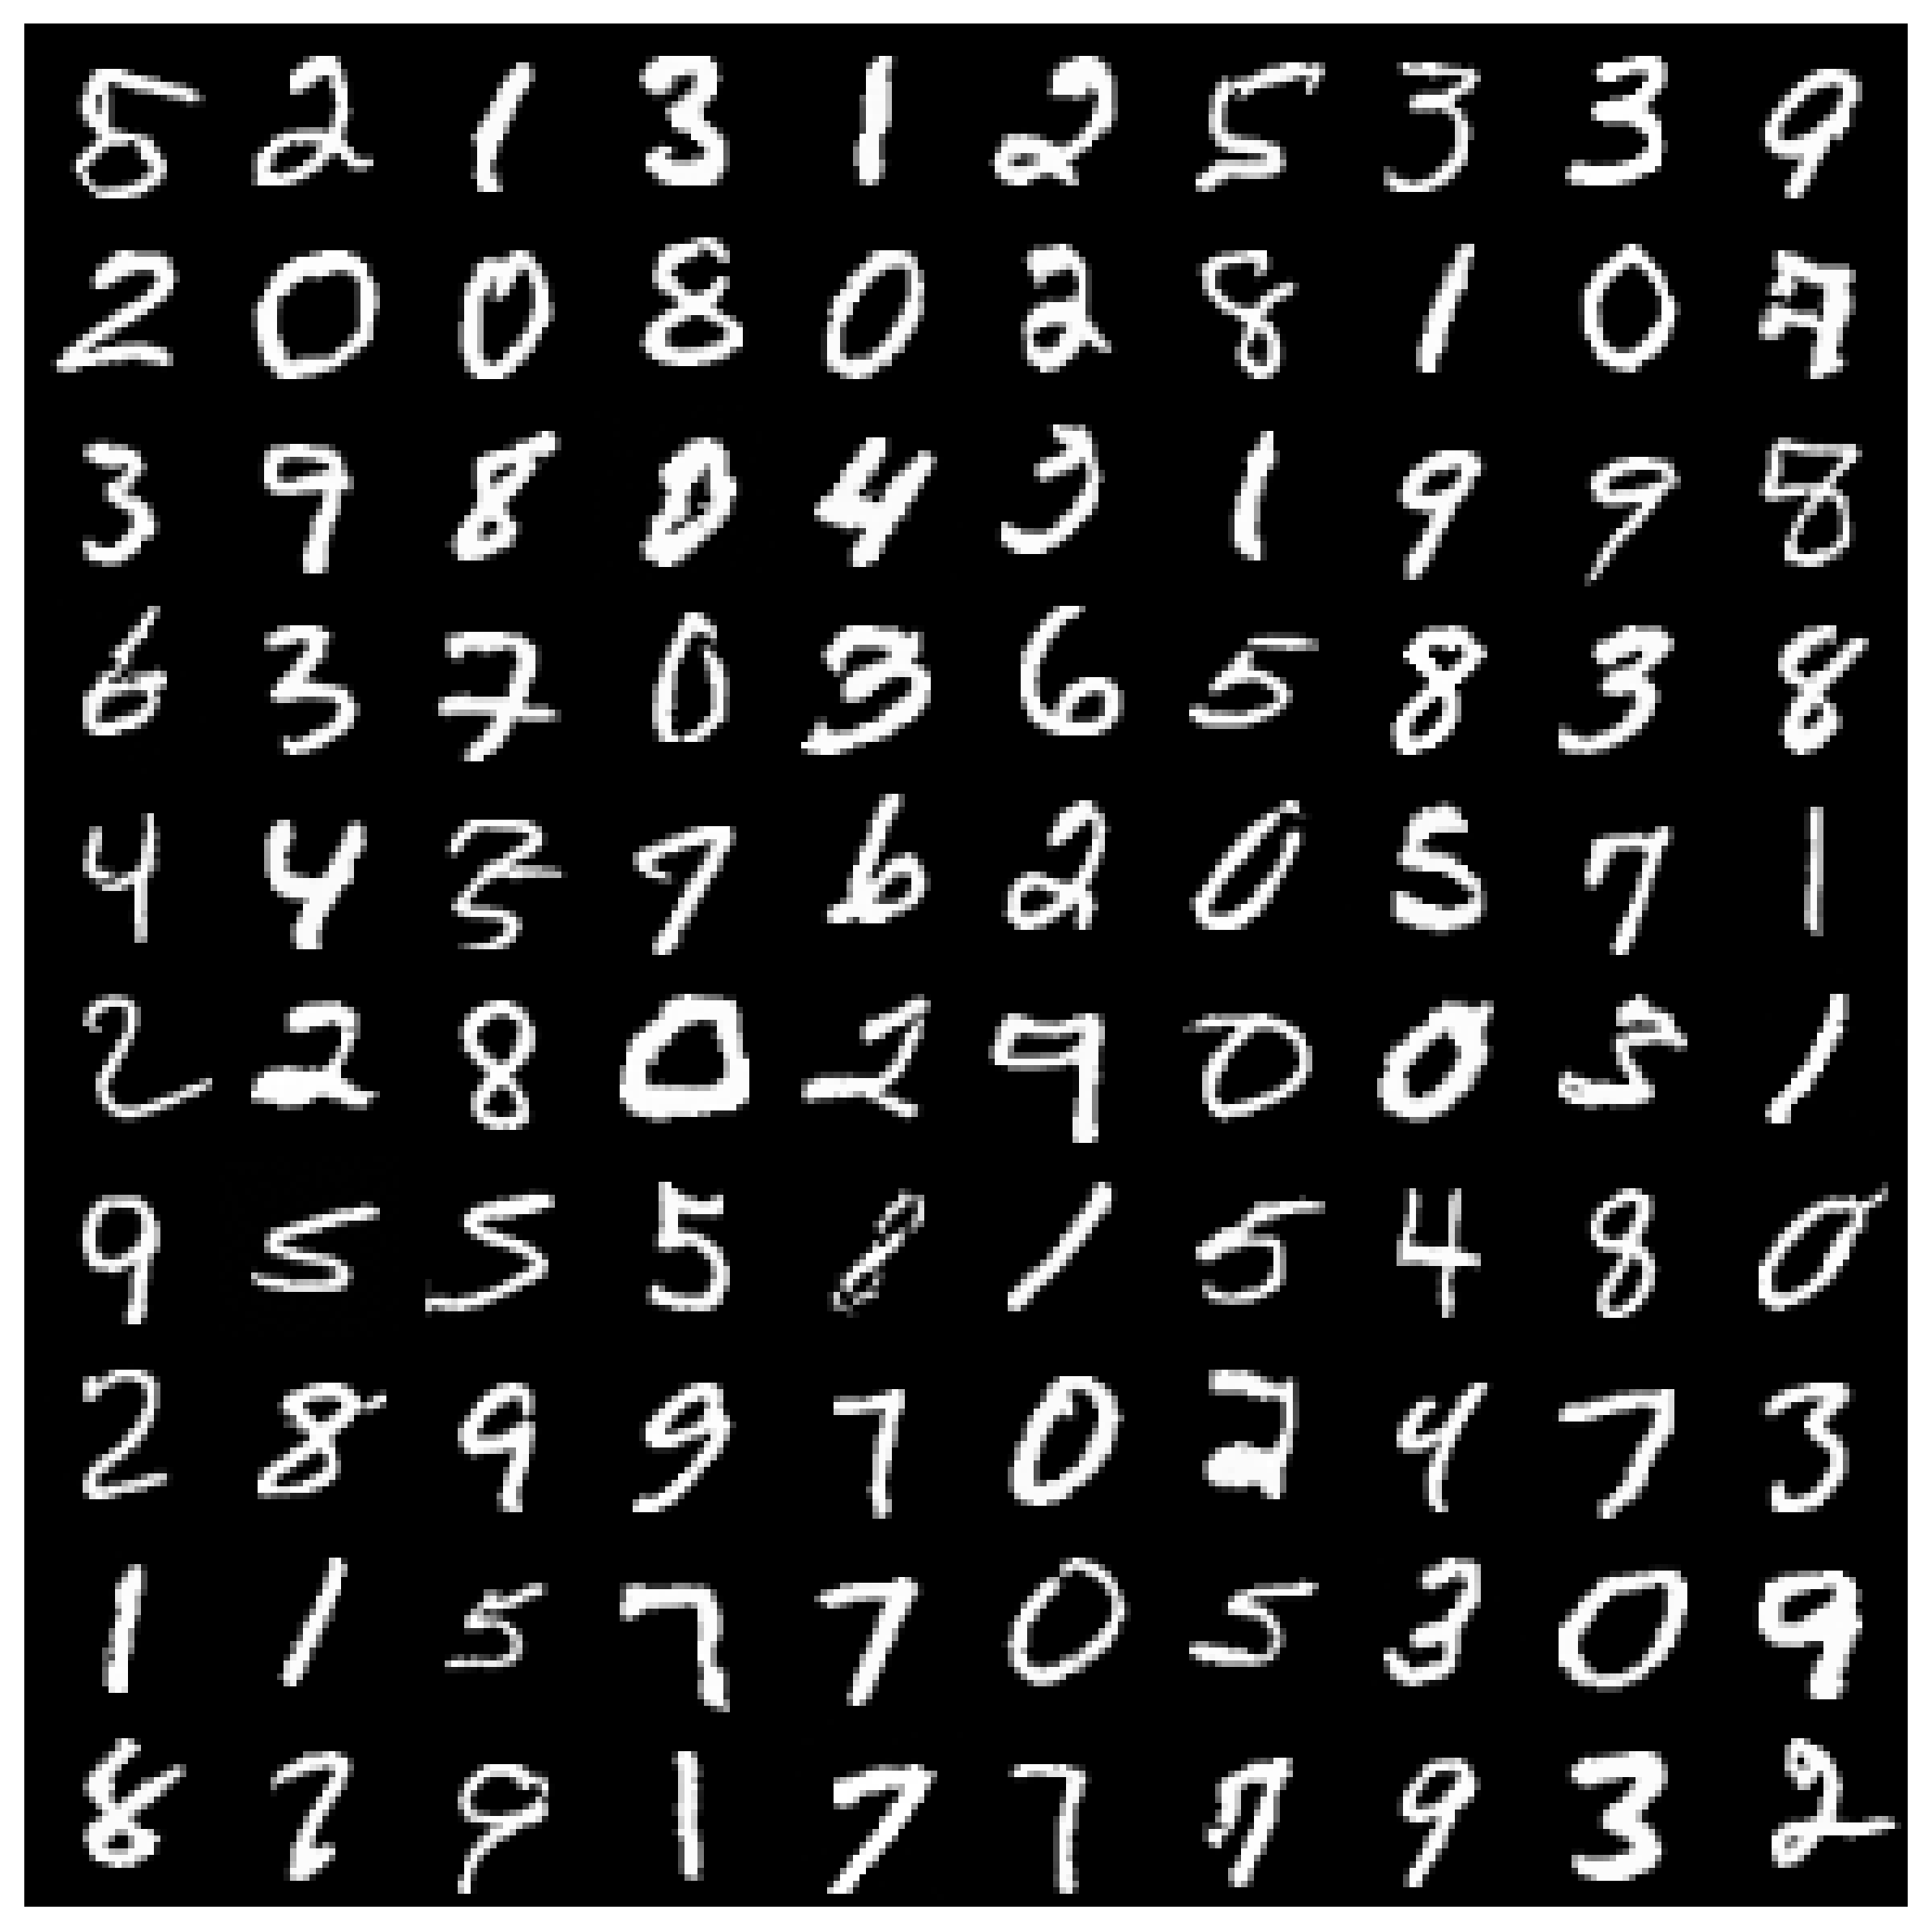

In [ ]:
x_0 = torch.randn(100, *data_shape).to(device)

x_t = x_0.clone()

N = 100

# Implement Euler Sampler
with torch.inference_mode():
  for i in range(N):
      t = i / N
      t_b = t * torch.ones(x_0.shape[0], device=x_0.device, dtype=x_0.dtype)
      v_pred = flow_model(x_t, t_b)
      x_t = x_t + v_pred * (1. / N)

plot_cifar_results(x_t)


In [ ]:
x_0 = torch.randn(30, *data_shape).to(device) * 0.5

x_1_euler = euler_sampler.sample_loop(x_0=x_0).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(x_0=x_0).trajectories[-1]

print(x_1.shape)  # torch.Size([20, 1, 28, 28])

torch.Size([96, 1, 28, 28])


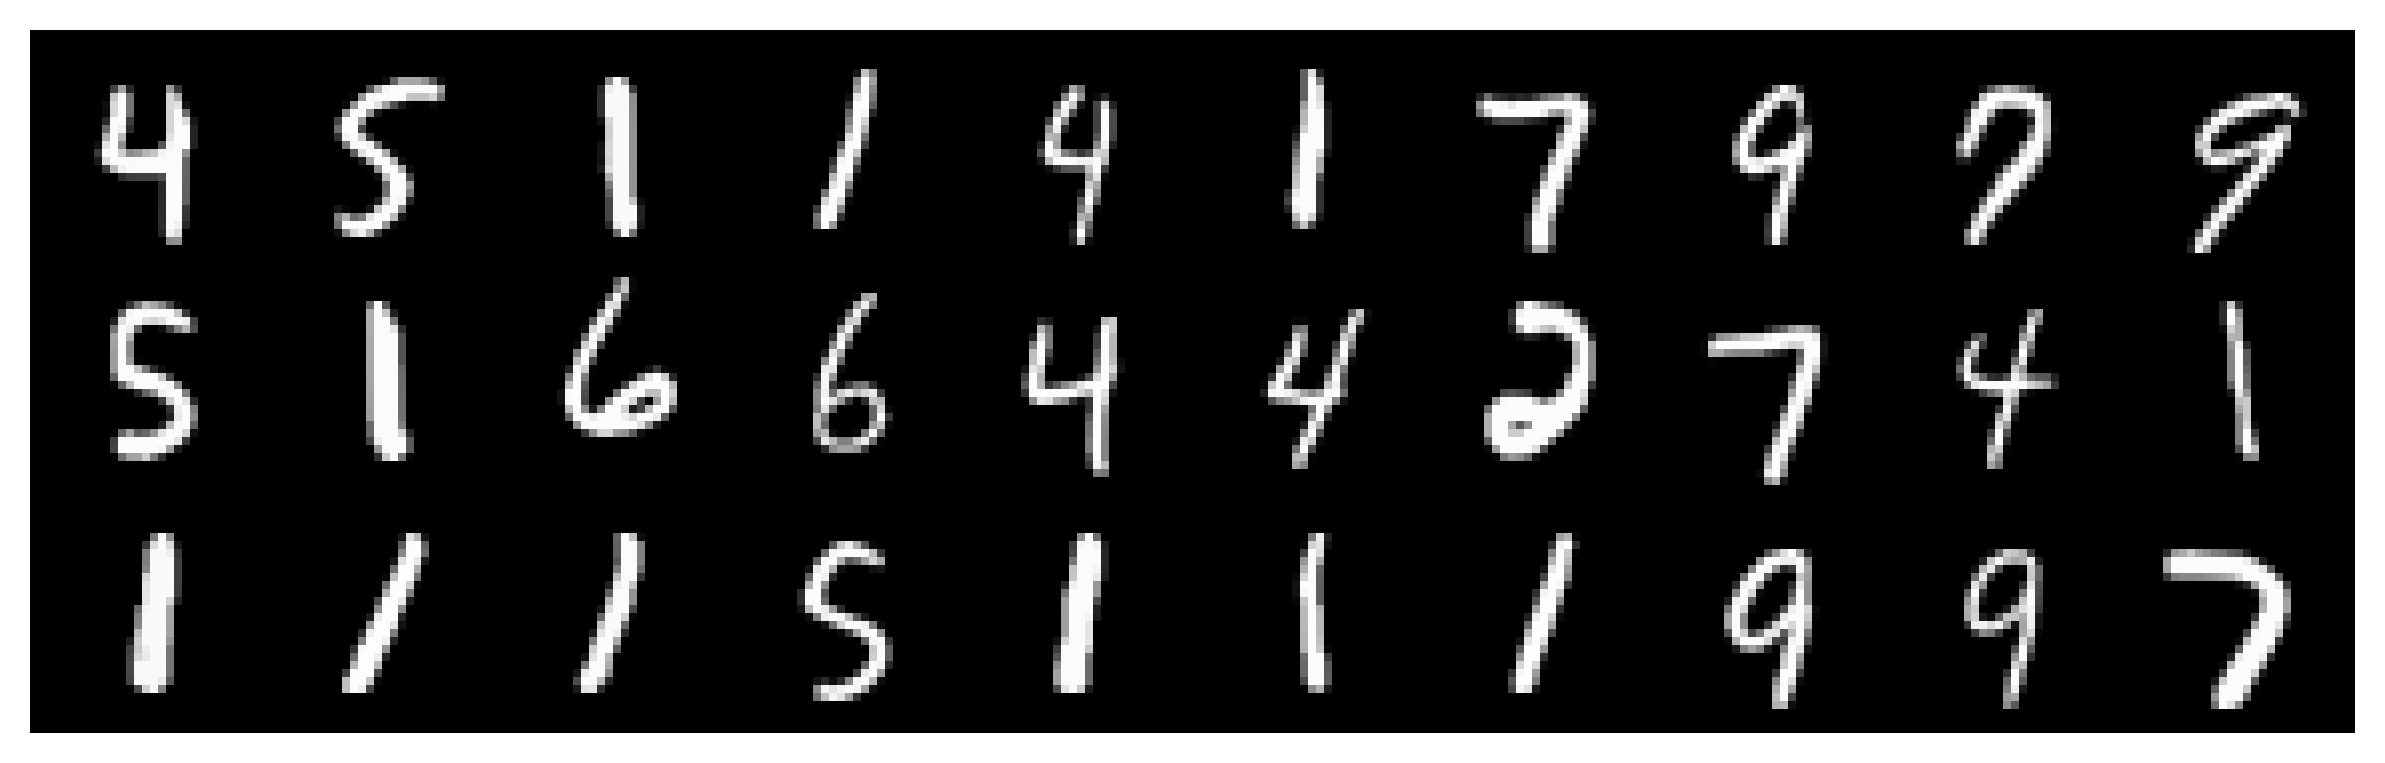

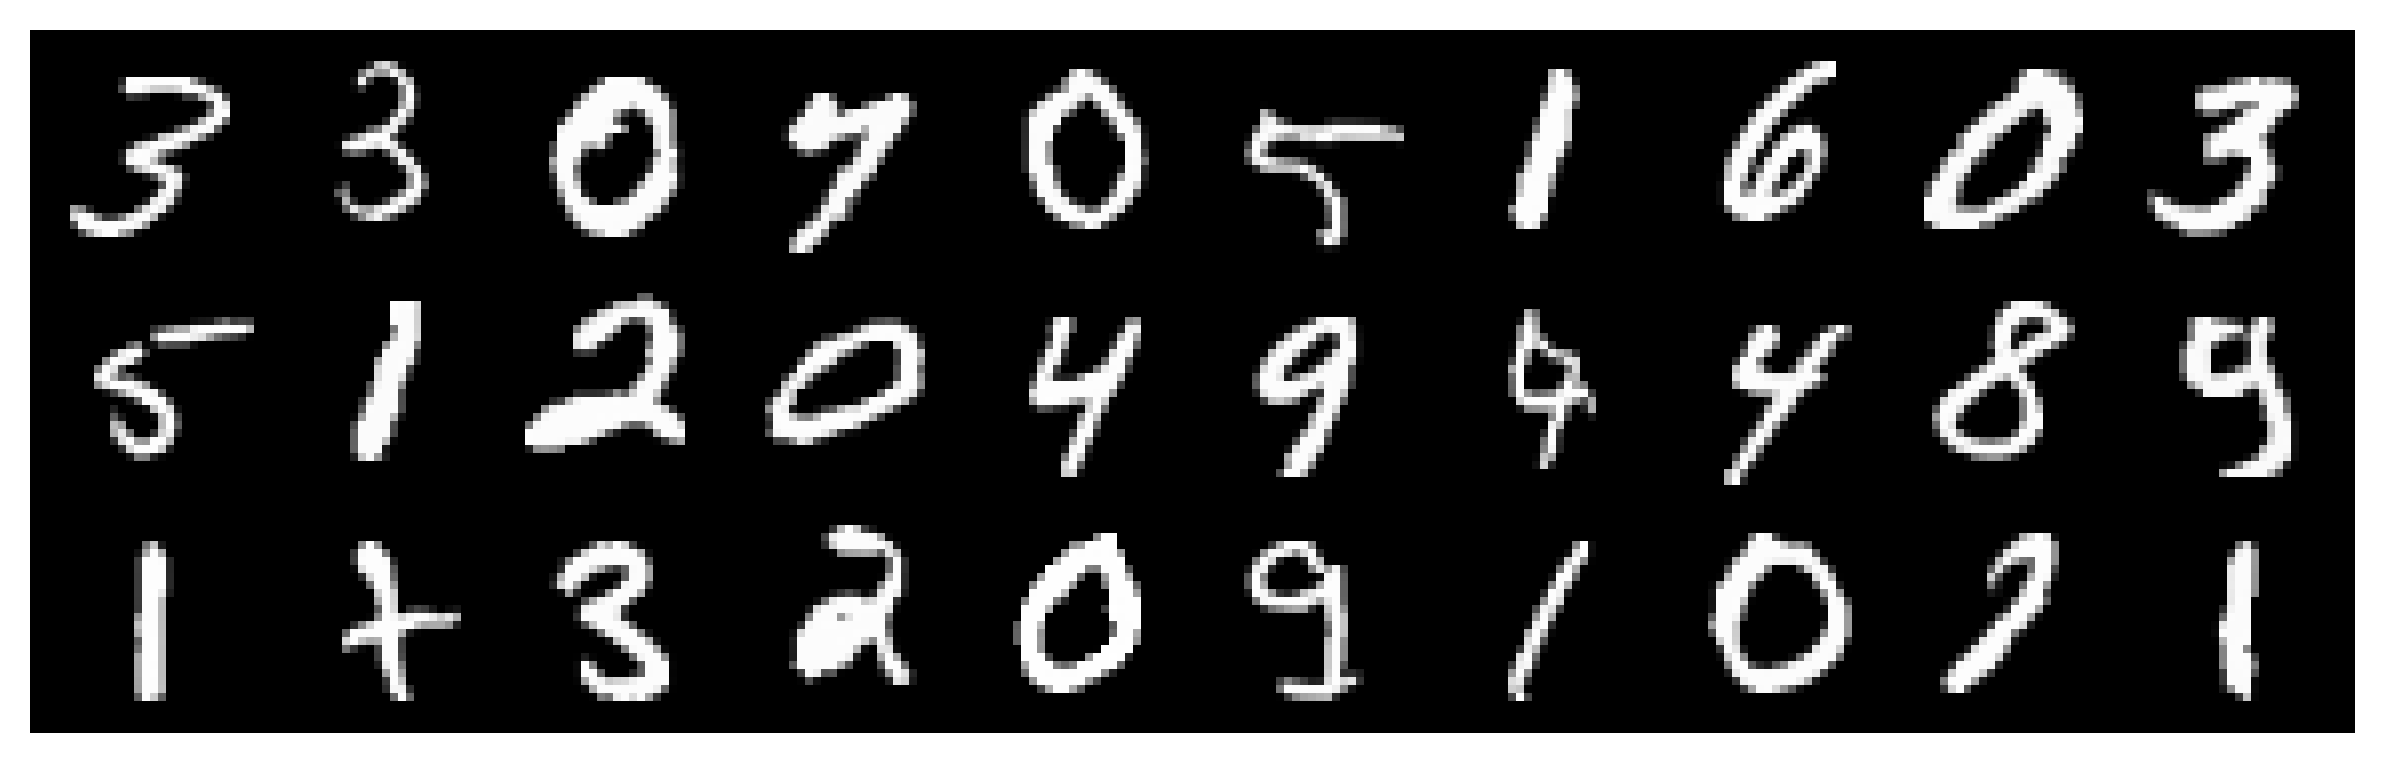

In [ ]:
plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

## Part 2 - Sampling Step Ablations

- **Small step counts (10-25)**: fastest updates but tends to produce blurrier, inconsistent digits.
- **Medium steps (50-75)**: good balance between runtime and fidelity; digits stay sharp without taking too long.
- **Large steps (100+)**: samples are extremely sharp and stable, yet sampling becomes noticeably slower.

We will sweep across these regimes below to visualize the trade-offs.

In [ ]:
from rectified_flow.samplers import EulerSampler

# Step counts to test; feel free to tweak.
sampling_step_grid = [2, 5, 10, 20, 50, 100]
sampling_seed = 314
num_eval_samples = 64

run_sampling_step_sweep = True  # flip to True to actually run the sweep
sampling_step_results = {}


def evaluate_sampling_steps(step_grid, *, sampler_cls=EulerSampler, seed=0):
    """Generate samples for different Euler step counts and report basic statistics."""
    torch.manual_seed(seed)
    base_noise = torch.randn(num_eval_samples, *data_shape, device=device)
    results = {}

    for steps in step_grid:
        sampler = sampler_cls(rf_inference, num_steps=steps)
        with torch.inference_mode():
            traj = sampler.sample_loop(x_0=base_noise).trajectories[-1]
        samples_cpu = traj.detach().cpu()
        stats = {
            "mean": float(samples_cpu.mean()),
            "std": float(samples_cpu.std()),
        }
        results[steps] = {"samples": samples_cpu, "stats": stats}
        print(f"[sampling] steps={steps:>3} | mean={stats['mean']:.4f} | std={stats['std']:.4f}")

    return results


if run_sampling_step_sweep:
    sampling_step_results = evaluate_sampling_steps(sampling_step_grid, seed=sampling_seed)


In [ ]:
def visualize_sampling_step_results(results, max_examples=64):
    if not results:
        print('No sampling results yet. Run the sweep first.')
        return

    for steps, payload in results.items():
        title = f'Euler sampler with {steps} steps'
        plot_cifar_results(payload['samples'][:max_examples], title=title)


visualize_sampling_step_results(sampling_step_results)


No sampling results yet. Run the sweep first.


### Part 16.2 – Effect of the number of sampling steps

We evaluated the Euler sampler with different numbers of integration steps
(e.g., 2, 5, 10, 20, 50, 100). Qualitatively:

- **Very small number of steps (2–5)**  
  - Sampling is very fast, but the digits tend to be **blurry** and sometimes
    look distorted or inconsistent.  
  - The transport path is quite coarse, so the samples do not fully follow the
    learned flow to the target distribution.

- **Moderate number of steps (10–20)**  
  - Images become noticeably **sharper** and more recognizable.  
  - This gives a good trade-off between sample quality and runtime.

- **Large number of steps (50–100)**  
  - Digits look the **sharpest** and most consistent with the MNIST training data.  
  - There are fewer artifacts and the digit shapes are cleaner, but sampling
    is correspondingly slower.

Overall, increasing the number of Euler steps improves sample sharpness and
consistency, but with diminishing returns: beyond a certain point (e.g.,
around 50–100 steps), the visual gains are smaller compared to the extra
computation time.


## Train Conditional Generation

In [ ]:
model_type = "unet"    # "mlp" or "unet" or "dit"

if model_type == "unet":
    from rectified_flow.models.unet import SongUNet, SongUNetConfig
    config = SongUNetConfig(
        img_resolution = 28,
        in_channels = 1,                  # Number of color channels at input.
        out_channels = 1,                 # Number of color channels at output.
        label_dim = 10,                    # Number of class labels (10 for MNIST).
        augment_dim = 0,                  # Augmentation label dimensionality, 0 = no augmentation.

        model_channels = 64,                # Base multiplier for the number of channels.
        channel_mult = [2, 2],              # Channel multipliers for each resolution.
        channel_mult_emb = 2,               # Multiplier for the dimensionality of the embedding vector.
        num_blocks = 2,                     # Number of residual blocks per resolution.
        attn_resolutions = [14],            # Resolutions at which to apply attention.
        dropout = 0.13,                     # Dropout probability of intermediate activations.
        label_dropout = 0.1,                # Dropout probability of class labels for classifier-free guidance.
        embedding_type = "positional",      # Timestep embedding type: 'positional' or 'fourier'.
        channel_mult_time = 1,              # Timestep embedding size: 1 for DDPM++, 2 for NCSN++.
        encoder_type = "standard",          # Encoder architecture: 'standard' or 'residual'.
        decoder_type = "standard",          # Decoder architecture: 'standard' or 'residual'.
        resample_filter = [1, 1]
    )
    flow_model = SongUNet(config)
    data_shape = (1, 28, 28)
elif model_type == "dit":
    raise NotImplementedError
else:
    raise ValueError(f"Unknown model type: {model_type}")

flow_model = flow_model.to(device)

print(f"Number of parameters in flow model: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")

ema_flow = EMAModel(flow_model, ema_halflife_kimg=1.0, ema_rampup_ratio=0.05)

optimizer = torch.optim.AdamW(
    flow_model.parameters(),
    lr=5e-4, weight_decay=0.01,
    betas=(0.9, 0.95)
)

compiled_flow = torch.compile(flow_model, mode="reduce-overhead", fullgraph=False, dynamic=False)

compiled_flow.train()
optimizer.zero_grad()

Number of parameters in flow model: 5,632,577


In [ ]:
epoch = 200
cur_nimg = 0

rf_train = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=compiled_flow,
    train_time_distribution="uniform",
    device=device,
)

try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

def safe_tqdm_write(msg: str):
    try:
        tqdm.write(msg)
    except Exception:
        print(msg)

zero_to_none = True
grad_clip_norm = None

global_step = 0
running_loss = None
smooth_alpha = 0.99

# test model
with torch.no_grad():
    batch = next(iter(train_dataloader))
    x_1, c = batch
    x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
    c = c.to(device, non_blocking=True)
    c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
    x_0 = torch.randn_like(x_1)
    t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)
    # print(x_1.shape, x_0.shape, c.shape, t.shape)
    v_pred = flow_model(x_1, t, c_onehot)
    sq_err = (v_pred - (x_1 - x_0)).pow(2).sum(dim=1)
    loss = sq_err.mean()
    safe_tqdm_write(f"Initial test loss: {loss.item():.4f}")

Initial test loss: 1.9292


In [ ]:
for ep in tqdm(range(epoch), desc="Epochs", position=0):
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
        c_onehot = c_onehot.to(device, non_blocking=True)

        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)
        t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)

        # --- forward (bf16 autocast) ---
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_t, dot_x_t = rf_train.get_interpolation(x_0=x_0, x_1=x_1, t=t)
            v_pred = rf_train.get_velocity(x_t, t, class_labels=c_onehot)

        # --- pure MSE loss in fp32 for stability ---
        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())
        mse_loss = float(loss.detach().item())

        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(rf_train.parameters(), grad_clip_norm)

        optimizer.step()

        global_step += 1
        cur_nimg += x_1.shape[0]
        ema_flow.update(cur_nimg=cur_nimg, batch_size=x_1.shape[0])

        loss_val = float(loss.detach().item())
        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * mse_loss
        )

        pbar.set_postfix({
            "mse_loss": f"{mse_loss:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    safe_tqdm_write(
        f"[epoch {ep+1}/{epoch}] steps={global_step:,} "
        f"mse_loss={mse_loss:.4f}, mse_loss_ema={running_loss:.4f}"
    )

    if ep % 10 == 0:
        flow_model.save_pretrained(f"./checkpoints/flow_mnist_unet_conditionalaa")
        ema_flow.save_pretrained(f"./checkpoints/flow_mnist_unet_conditionalaa")

print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

ep 1/200:   0%|          | 0/118 [00:00<?, ?it/s]

skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_24). Found from : 
   File "/content/rectified-flow/rectified_flow/models/unet.py", line 387, in forward
    x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
  File "/content/rectified-flow/rectified_flow/models/unet.py", line 185, in forward
    x = x * self.skip_scale

skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_24). Found from : 
   File "/content/rectified-flow/rectified_flow/models/unet.py", line 387, in forward
    x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
  File "/content/rectified-flow/rectified_flow/models/unet.py", line 185, in forward
    x = x * self.skip_scale



[epoch 1/200] steps=118 mse_loss=0.2272, mse_loss_ema=0.8427
Configuration saved to ./checkpoints/flow_mnist_unet_conditionalaa/unet_config.json
Model weights saved to ./checkpoints/flow_mnist_unet_conditionalaa/unet_model.pt
EMA model weights saved to ./checkpoints/flow_mnist_unet_conditionalaa/unet_ema.pt


ep 2/200:   0%|          | 0/118 [00:00<?, ?it/s]

...

ep 154/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 154/200] steps=18,172 mse_loss=0.1512, mse_loss_ema=0.1470


ep 155/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 155/200] steps=18,290 mse_loss=0.1556, mse_loss_ema=0.1469


ep 156/200:   0%|          | 0/118 [00:00<?, ?it/s]

### Class Conditional Generation without CFG

In [ ]:
from rectified_flow.samplers import EulerSampler, SDESampler

# flow_model = SongUNet.from_pretrained(f"./checkpoints/flow_mnist_unet_conditional", use_ema=False).to(device)

model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

euler_sampler = EulerSampler(rf_inference, num_steps=50, num_samples=100)
sde_sampler = SDESampler(rf_inference, num_steps=50, noise_scale=50, noise_decay_rate=0., num_samples=100)

In [ ]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

In [ ]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

### Class Conditional Generation with CFG

In [ ]:
from rectified_flow.samplers import EulerSampler, SDESampler

flow_model = SongUNet.from_pretrained(f"./checkpoints/flow_mnist_unet_conditionalaa", use_ema=True).to(device)

model_inference = flow_model.eval()

def velocity_with_cfg(x, t, class_labels=None, cfg_scale=3.5):
    assert class_labels is not None
    v_uncond = model_inference(x, t, torch.zeros_like(class_labels))
    v_cond = model_inference(x, t, class_labels)
    return cfg_scale * v_cond + (1. - cfg_scale) * v_uncond

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=velocity_with_cfg,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

euler_sampler = EulerSampler(rf_inference, num_steps=50, num_samples=100)
sde_sampler = SDESampler(rf_inference, num_steps=50, noise_scale=5, noise_decay_rate=0., num_samples=100)

In [ ]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

In [ ]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

## Part 3 - Conditional Generation and Classifier-Free Guidance

These cells streamline conditional sampling along with a Classifier-Free Guidance (CFG) sweep. Provide a conditional Rectified Flow model (either the one trained above or a checkpoint) and toggle the flags to generate digits for different CFG scales.

In [ ]:
from rectified_flow.samplers import EulerSampler

# Plug in the conditional flow model you want to evaluate.
# By default we reuse `flow_model`, but you can load EMA weights or another checkpoint here.
conditional_flow_model = flow_model.eval()

rf_conditional = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=conditional_flow_model,
    device=device,
)

samples_per_class = 10
cond_sampling_steps = 50
classes = torch.arange(10, device=device).repeat_interleave(samples_per_class)
class_onehot = torch.nn.functional.one_hot(classes, num_classes=10).float()

run_conditional_sampling = False
conditional_samples = None


def sample_conditional_digits(num_steps, *, seed=0):
    torch.manual_seed(seed)
    x0 = torch.randn(class_onehot.shape[0], *data_shape, device=device)
    sampler = EulerSampler(rf_conditional, num_steps=num_steps)
    with torch.inference_mode():
        traj = sampler.sample_loop(x_0=x0, class_labels=class_onehot).trajectories[-1]
    return traj.detach().cpu()


if run_conditional_sampling:
    conditional_samples = sample_conditional_digits(cond_sampling_steps)
    plot_cifar_results(conditional_samples, title=f'Conditional samples ({cond_sampling_steps} steps)')


In [ ]:
class CFGVelocityWrapper(torch.nn.Module):
    def __init__(self, base_model, scale):
        super().__init__()
        self.base_model = base_model
        self.scale = scale

    def forward(self, x, t, class_labels=None):
        if class_labels is None:
            raise ValueError('CFG requires class labels for conditioning.')
        null_labels = torch.zeros_like(class_labels)
        v_uncond = self.base_model(x, t, null_labels)
        v_cond = self.base_model(x, t, class_labels)
        return v_uncond + self.scale * (v_cond - v_uncond)


cfg_scales = [0.0, 0.5, 1.0, 2.0, 3.0]
cfg_sampling_steps = 50
run_cfg_sweep = True
cfg_results = {}


def run_cfg_sampling(scales, *, seed=0):
    torch.manual_seed(seed)
    x0 = torch.randn(class_onehot.shape[0], *data_shape, device=device)
    results = {}

    for scale in scales:
        cfg_velocity = CFGVelocityWrapper(conditional_flow_model, scale)
        rf_cfg = RectifiedFlow(
            data_shape=data_shape,
            velocity_field=cfg_velocity,
            device=device,
        )
        sampler = EulerSampler(rf_cfg, num_steps=cfg_sampling_steps)
        with torch.inference_mode():
            traj = sampler.sample_loop(x_0=x0, class_labels=class_onehot).trajectories[-1]
        samples_cpu = traj.detach().cpu()
        results[scale] = samples_cpu
        print(f"[cfg] scale={scale:.1f} | mean={samples_cpu.mean():.4f} | std={samples_cpu.std():.4f}")

    return results


if run_cfg_sweep:
    cfg_results = run_cfg_sampling(cfg_scales)


In [ ]:
def visualize_cfg_results(results, max_examples=64):
    if not results:
        print('No CFG runs recorded yet.')
        return

    for scale, samples in results.items():
        title = f'CFG scale {scale:.1f}'
        plot_cifar_results(samples[:max_examples], title=title)


visualize_cfg_results(cfg_results)


### Part 16.3 - Conditional generation and Classifier-Free Guidance (CFG)

Classifier-free guidance mixes the unconditional and conditional velocities:

\[ v_{\mathrm{CFG}}(x, t; s) = v(x, t, \varnothing) + s \cdot (v(x, t, y) - v(x, t, \varnothing)) \]

where `s = cfg_scale`. Tuning `s` trades off class faithfulness and diversity:

- **s = 0 (uncond.)** - Fast and diverse, but digits may resemble random classes.
- **s around 1-2** - Best trade-off: digits are sharp and match the requested class with little slowdown.
- **s >= 3** - Very class-consistent and crisp, though sampling slows slightly and diversity drops.

The experiments below use this formula to compare multiple `cfg_scale` settings.